# Exploration, visualization and classification of EEG signals

In [4]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install mne

   ---------------------------------------- 0.0/7.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.4 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/7.4 MB 2.8 MB/s eta 0:00:03
   -------- ------------------------------- 1.6/7.4 MB 2.9 MB/s eta 0:00:03
   ------------ --------------------------- 2.4/7.4 MB 3.1 MB/s eta 0:00:02
   -------------- ------------------------- 2.6/7.4 MB 2.8 MB/s eta 0:00:02
   ----------------- ---------------------- 3.1/7.4 MB 2.7 MB/s eta 0:00:02
   ------------------ --------------------- 3.4/7.4 MB 2.4 MB/s eta 0:00:02
   ------------------- -------------------- 3.7/7.4 MB 2.4 MB/s eta 0:00:02
   ---------------------- ----------------- 4.2/7.4 MB 2.3 MB/s eta 0:00:02
   ------------------------- -------------- 4.7/7.4 MB 2.3 MB/s eta 0:00:02
   ---------------------------- ----------- 5.2/7.4 MB 2.3 MB/s eta 0:00:01
   ------------------------------- -------- 5.8/7.4 MB 2.3 MB/s eta 0:00:01
   -----------------------

In [22]:
import os 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

### Reading of the pdf file

In [75]:
edf_path = r"C:\Users\iness\sleep-edf-project\data\sleep-cassette\SC4001E0-PSG.edf"
raw = mne.io.read_raw_edf(edf_path, preload=True)


Extracting EDF parameters from C:\Users\iness\sleep-edf-project\data\sleep-cassette\SC4001E0-PSG.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7949999  =      0.000 ... 79499.990 secs...


C:\Users\iness\AppData\Local\Temp\ipykernel_11748\2711479337.py:2: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True)
C:\Users\iness\AppData\Local\Temp\ipykernel_11748\2711479337.py:2: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True)
C:\Users\iness\AppData\Local\Temp\ipykernel_11748\2711479337.py:2: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(edf_path, preload=True)


In [77]:
print ("Available Channels: ")
print ("raw.ch_names")

raw.info

Available Channels: 
raw.ch_names


<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fpz-Cz, EEG Pz-Oz, EOG horizontal, Resp oro-nasal, EMG ...
 chs: 7 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 50.0 Hz
 meas_date: 1989-04-24 16:13:00 UTC
 nchan: 7
 projs: []
 sfreq: 100.0 Hz
 subject_info: <subject_info | his_id: X, sex: 2, first_name: Female, last_name: 33yr>
>

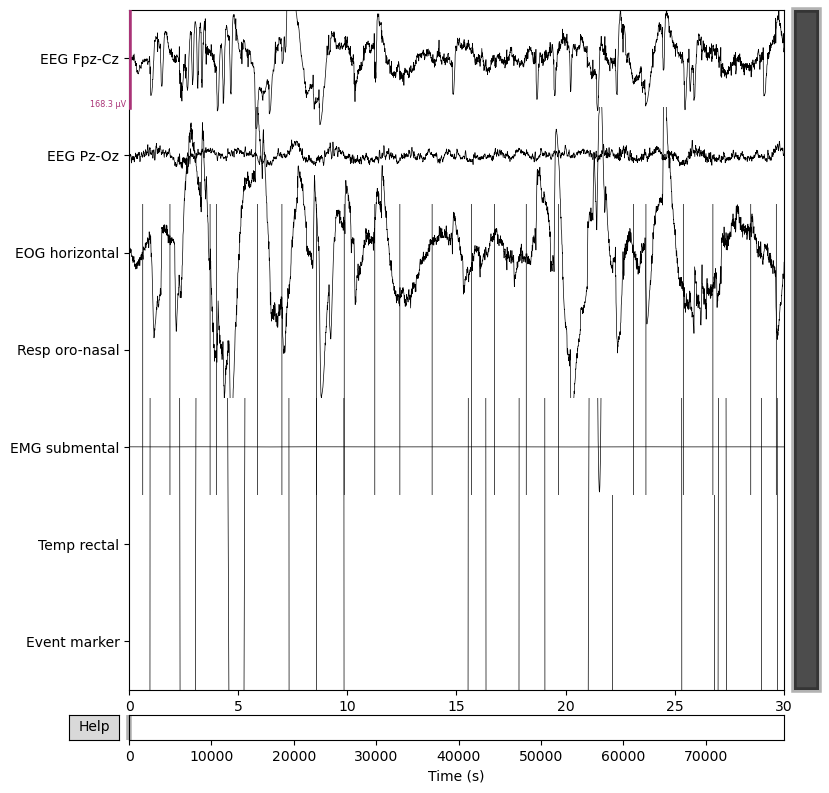

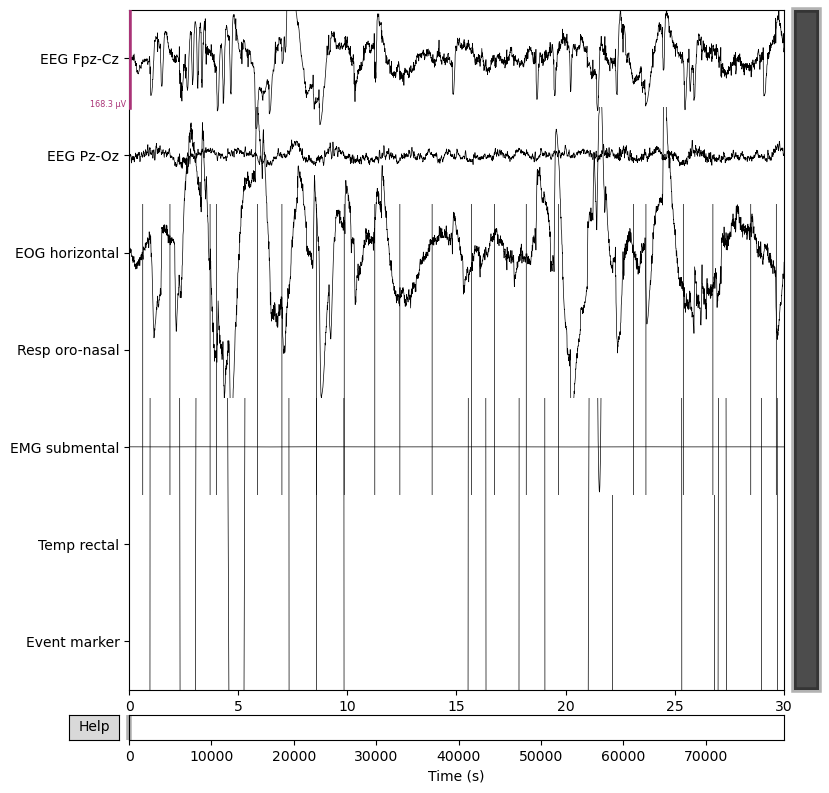

In [85]:
raw.plot (duration = 30, scalings = "auto")

### Filtering the signal, to avoid artifact and noise

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 661 samples (6.610 s)



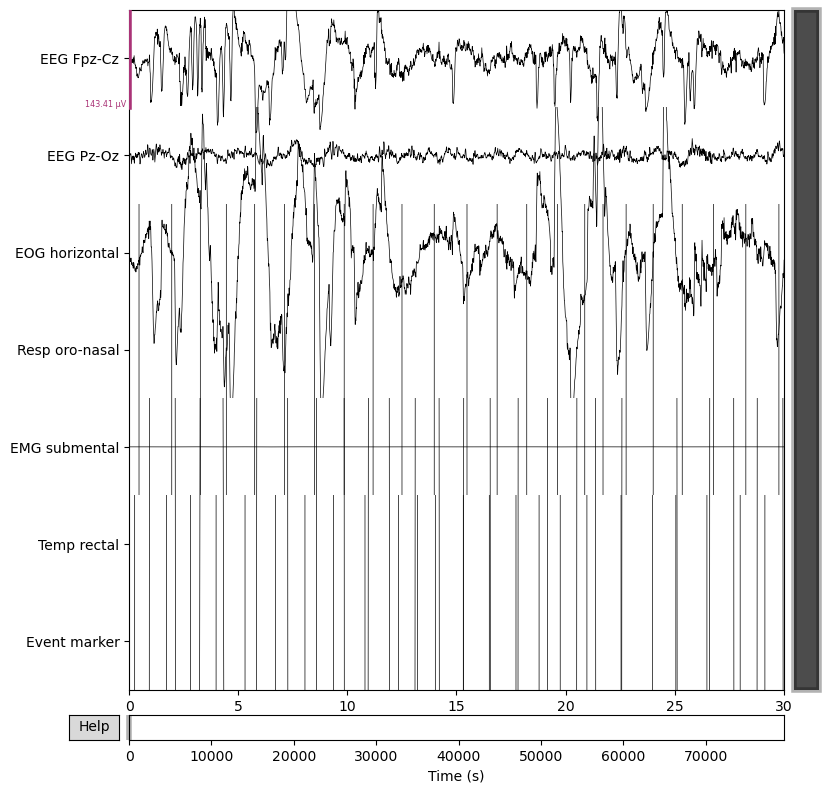

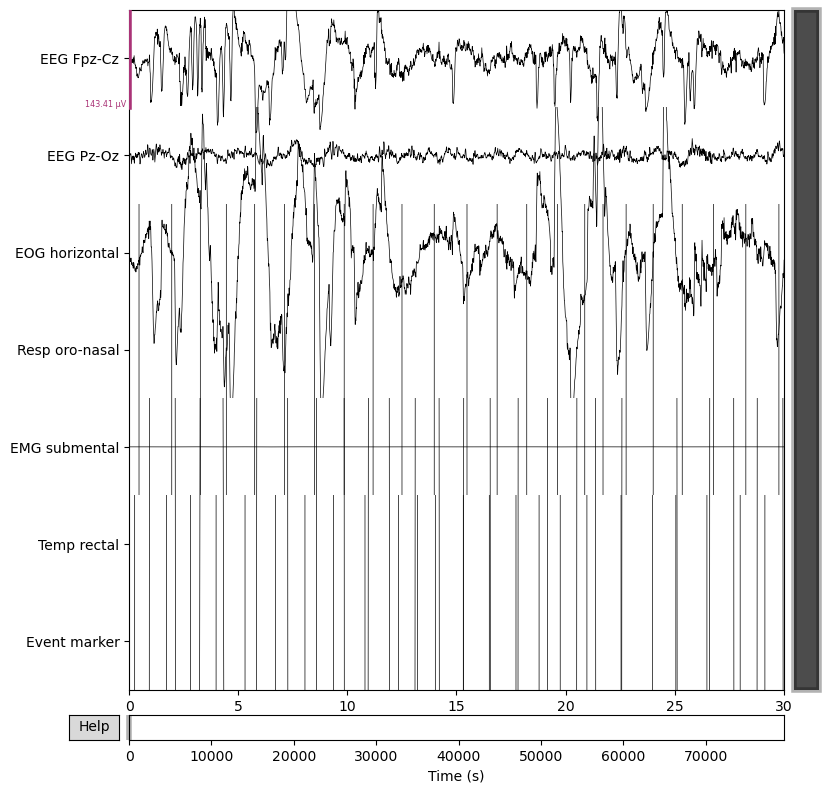

In [89]:
raw_filtered = raw.copy().filter (l_freq = 0.5, h_freq = 30.0)
raw_filtered.plot (duration = 30, scalings = "auto")

In [95]:
data, times = raw_filtered [:1]
df = pd.DataFrame ({
    "Time": times,
    "Signal": data [0]
})
df.head ()

,Time,Signal
0,0.00,1.016440e-20
1,0.01,-6.238533e-06
2,0.02,-5.336002e-06
3,0.03,-5.778387e-06
4,0.04,-1.039968e-05


### Obtaining the channel names available

In [101]:
print(raw.ch_names)


['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental', 'Temp rectal', 'Event marker']


### Chosing the channels for the analysis

In [103]:
raw.pick_channels (["EEG Pz-Oz"])

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


<RawEDF | SC4001E0-PSG.edf, 1 x 7950000 (79500.0 s), ~60.7 MiB, data loaded>

In [109]:
psd = raw_filtered.compute_psd(fmin=0.5, fmax=40, n_fft=2048)
psds, freqs = psd.get_data(return_freqs=True)


Effective window size : 20.480 (s)


### Defining the different bands in frenquency

In [113]:
def bandpower (psds, freqs, fmin, fmax):
    band = (freqs >= fmin) & (freqs <= fmax)
    return np.mean (psds [:, band], axis = 1)

delta = bandpower (psds, freqs, 0.5, 4)
theta = bandpower (psds, freqs, 4, 8)
alpha = bandpower (psds, freqs, 8, 13)
beta = bandpower (psds, freqs, 13, 20)

In [115]:
df_bands = pd.DataFrame ({
    "Delta":delta,
    "Theta": theta,
    "Alpha": alpha,
    "Beta": beta
})
df.head() 

,Time,Signal
0,0.00,1.016440e-20
1,0.01,-6.238533e-06
2,0.02,-5.336002e-06
3,0.03,-5.778387e-06
4,0.04,-1.039968e-05


### Atribution of the bands to the respetive state of consciousness

In [121]:
def State_of_consciousness (delta, theta, alpha, beta):
    if delta > theta and delta >alpha:
        return "Deep Sleep"
    elif theta >alpha:
        return "Drownsiness"
    elif alpha > beta:
        return "Awake - Relaxed"
    else:
        return "Awake - Alert"

df_bands ["State"] = [
    State_of_consciousness (d,t,a,b)
    for d,t,a,b in zip(delta,theta,alpha,beta)
]

print("DataFrame with column 'State':")
print(df_bandas.head())

DataFrame with column 'State':
          Delta         Theta         Alpha          Beta      Estado  \
0  1.057808e-10  9.096346e-12  1.717183e-12  8.051928e-13  Deep Sleep   
1  1.602871e-11  2.229871e-12  1.169501e-12  4.840238e-13  Deep Sleep   
2  5.715264e-10  2.379061e-11  6.659908e-12  4.760381e-12  Deep Sleep   
3  1.295644e+01  1.479317e-02  4.603455e-03  1.933656e-03  Deep Sleep   
4  2.419877e-17  1.257338e-20  3.895927e-21  1.634785e-21  Deep Sleep   

        State  
0  Deep Sleep  
1  Deep Sleep  
2  Deep Sleep  
3  Deep Sleep  
4  Deep Sleep  


# The end
## Made by Inês Santos
### Project done with the support of https://mne.tools/stable/index.html.